<h1 style="color : blue"> Aula03.5-ML -SVR x RLM X RFR </h1>


<h2 style="color : green">Support Vector Regression - SVR </h2>

Diferente da Regressão Linear tradicional, que tenta minimizar o erro total (o quadrado das distâncias), o SVR trabalha com um conceito de "Margem de Tolerância" ($\epsilon$).

Imagine uma estrada: o SVR tenta encaixar o máximo de pontos possíveis dentro dessa estrada (a margem), ignorando erros que sejam menores que esse limite. Ele busca uma função que seja o mais "plana" possível, mas que ainda represente bem os dados. Quando os dados não seguem uma linha reta, o SVR usa o "Truque do Kernel" para mapear os dados em uma dimensão superior onde eles se tornam lineares.


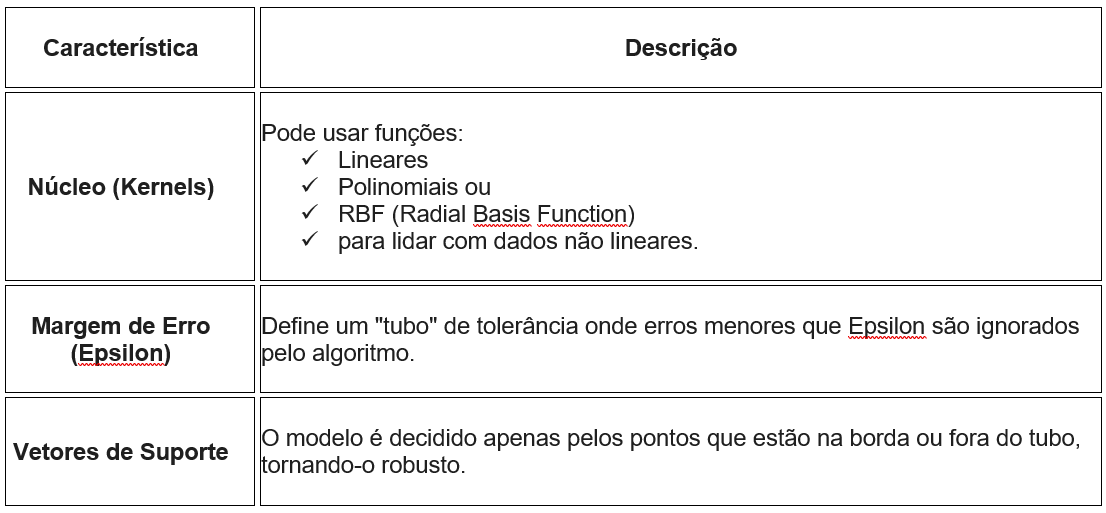

Os parâmetros livres no modelo são C e epsilon.

A implementação é baseada na libsvm. A complexidade de tempo do ajuste é mais que quadrática em relação ao número de amostras, o que dificulta a escalabilidade para conjuntos de dados com mais de algumas dezenas de milhares de amostras. Para conjuntos de dados grandes, considere usar o método `kernel_approximation` LinearSVRou, SGDRegressorem vez disso, possivelmente após um Nystroemtransformador ou outra aproximação de kernel .

o SVR (Support Vector Regression) funciona de forma diferente da Regressão Linear: ele busca uma "margem de tolerância" ($\epsilon$) onde os erros não são penalizados, tornando-o muito robusto contra outliers.

<pre>
    class sklearn.svm. SVR ( * , kernel = 'rbf' , degree = 3 , gamma = 'scale' , coef0 = 0.0 , tol = 0.001 , C = 1.0 , epsilon = 0.1 , shrinking = True , cache_size = 200 , verbose = False , max_iter = -1 )

</pre>

https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.svm.LinearSVR.html?_x_tr_sl=en&_x_tr_tl=pt&_x_tr_hl=pt&_x_tr_pto=tc


<h2 style="color : green">Vantagens vs. x Desvantagens</h2>

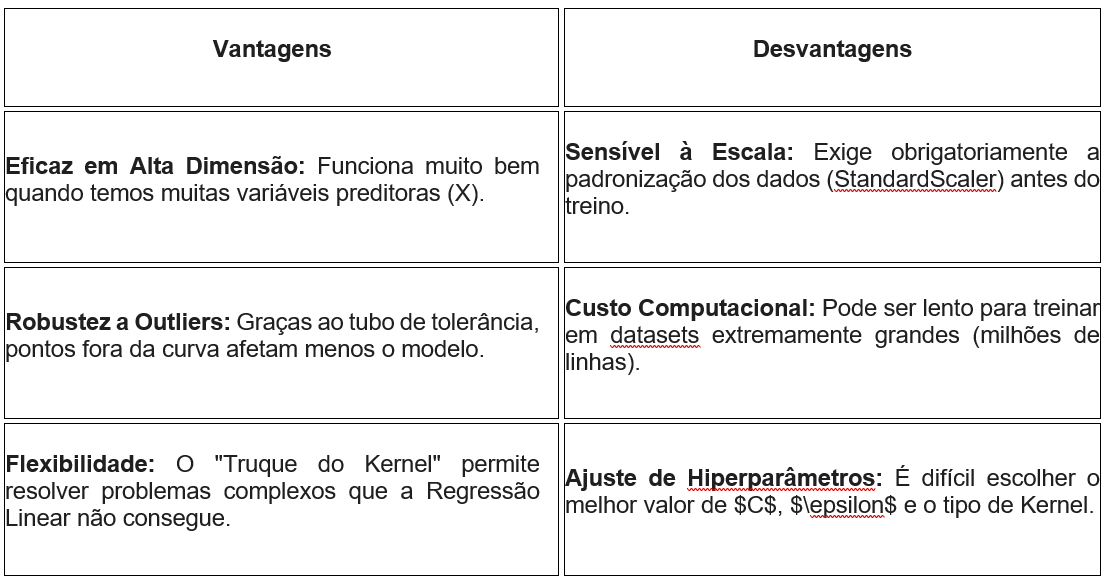


<h2 style="color : green"> Cases Reais e Exemplos de Aplicação </h2>
<pre>
1.	Previsão de Preços de Imóveis: Onde a relação entre metragem e preço nem sempre é linear e existem muitas variáveis (bairro, andar, idade).
2.	Mercado Financeiro (Stock Market): Previsão de preços de ações, onde o SVR consegue captar ten-dências complexas de curto prazo.
3.	Engenharia de Materiais: Prever a resistência de um novo composto químico baseado em suas proprie-dades moleculares.
4.	Consumo de Energia: Estimar a demanda elétrica de uma cidade baseando-se em temperatura, hora do dia e feriados.
</pre>




Semelhante ao SVR com o parâmetro kernel='linear', mas implementado em termos de liblinear em vez de libsvm, portanto, tem mais flexibilidade na escolha de penalidades e funções de perda e deve escalar melhor para um grande número de amostras.

As principais diferenças entre as duas implementações LinearSVRresidem SVRna função de perda utilizada por padrão e no tratamento da regularização do intercepto.

Esta classe suporta entradas densas e esparsas.

o SVR (Support Vector Regression), vamos focar agora em como medir se o "tubo" de predição que criamos está realmente calibrado.Como o SVR é um algoritmo de regressão, utilizamos métricas que calculam a distância entre o que o modelo previu e o valor real. No entanto, o SVR tem uma sensibilidade especial ao erro devido ao seu parâmetro $\epsilon$ (epsilon).🔍 Definição de Métricas para SVRDiferente da classificação (onde medimos acertos e erros), na regressão medimos a magnitude do resíduo. No SVR, o objetivo é que o resíduo (erro) de cada ponto fique dentro da margem de tolerância estabelecida.


<h2 style="color : green">Atenção </h2>

O SVR é extremamente sensível à escala dos dados. Por isso, no script abaixo, utilizaremos um Pipeline. O Pipeline garante que os dados sejam padronizados ($z-score$) antes de entrarem no modelo, evitando que uma variável com números maiores domine as outras injustamente.

<h2 style="color : green"> Dica do Professor para a Prática </h2>
Ao implementar o SVR no Dashboard, lembrem de uma regra de ouro: O SVR odeia dados em escalas diferentes. 
Se a variável Investimento vai de 0 a 100.000 e Vendedores vai de 1 a 20, o SVR vai ignorar os vendedores. Vocês devem usar o StandardScaler do Scikit-Learn antes de dar o .fit().

O SVR é chamado de "Regressão Robusta". Ele não tenta passar por todos os pontos, ele tenta criar um caminho onde a maioria dos pontos se sinta confortável!



<h2 style="color : green">Tabela 1: Principais Métricas de Avaliação </h2>

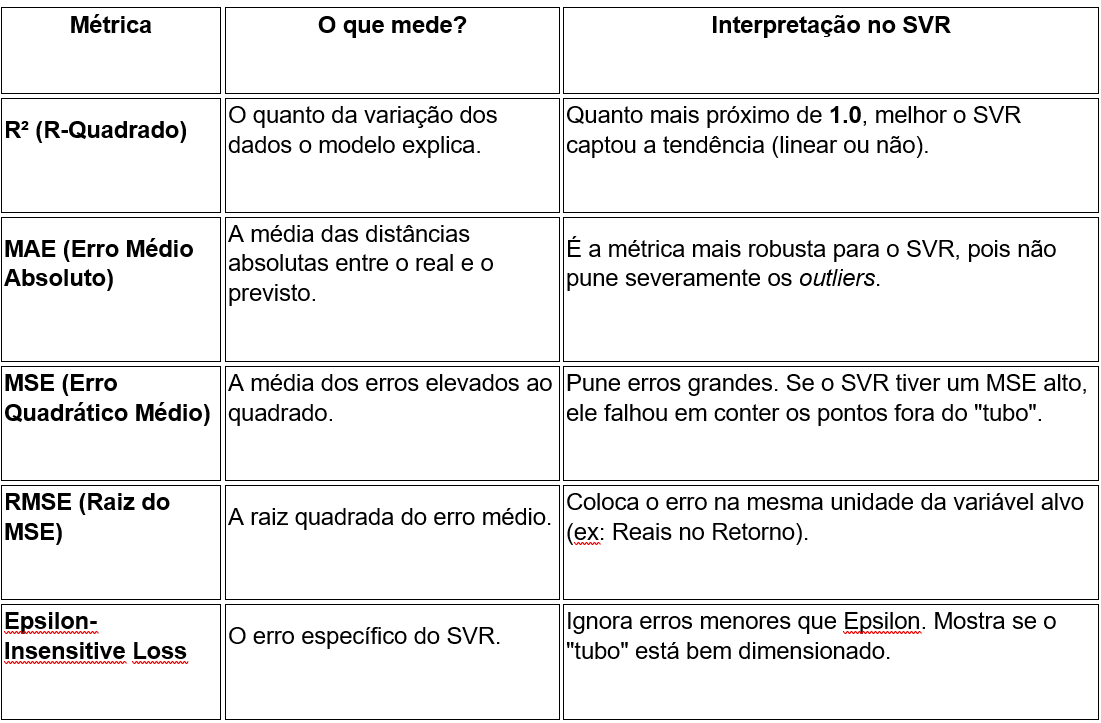


<h2 style="color : green"> Tabela 2: Resumo Estruturado do SVR </h2>

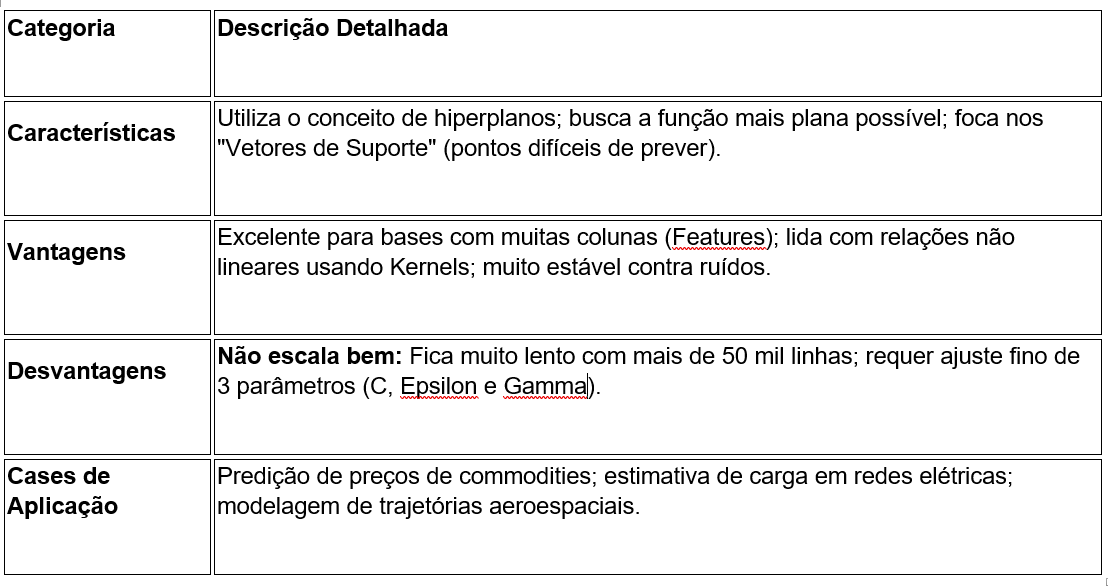


<h2 style="color : green"> Dica Prática do Professor </h2>
<pre>
Quando vocês estiverem analisando os resultados do SVR no Dashboard:
    
1)Olhar primeiro o MAE: Como o SVR tenta ignorar erros pequenos, o MAE costuma ser mais "generoso" com ele do que o MSE.
2)Cuidado com o C: Se o seu erro (MAE) estiver muito alto, tente aumentar o parâmetro C. Isso faz com que o modelo "se importe mais" com os pontos       fora do tubo, embora possa gerar overfitting.
3)Padronização: Vou repetir porque isso derruba muito aluno em prova: Sempre use StandardScaler. Sem isso, o SVR tentará tratar o Investimento           (número grande) como muito mais importante que a Quantidade de Vendedores (número pequeno).
</pre>





<h2 style="color : green"> Exemplo de concelamentos </h2>
Você foi contratado por uma empresa com mais de 800 mil clientes para um projeto de Dados. Recentemente a empresa percebeu que da sua base total de clientes, a maioria são clientes inativos, ou seja, que já cancelaram o serviço.

Precisando melhorar seus resultados ela quer conseguir entender os principais motivos desses cancelamentos e quais as ações mais eficientes para reduzir esse número.

<h2 style="color : green">Roteiro do Projeto</h2>
<ol>
<li><b>Passo 1:</b> Carregamento e Inspeção: Importar o data set (base de dados), </li>
<li><b>Passo 2:</b> Visualizar o data set (base de dados)</li>
<li><b>Passo 3:</b>  EDA (Análise Exploratória): Corrigir erros no Dataframe: Engenharia de Recurso,  Limpeza (Cleaning), Localizar e corrigir os valores errados da base de dados</li>
     <ul>
        <li> <b>Tratamento de valores Nulos </b></li>
         <li> <b>Tratamento de valores  ausentes</b></li>
       </ul>
<li><b>Passo 4:</b> Engenharia de Dados</b></li>
       <ul>
        <li><b>One-Hot Encoding (Variáveis Categóricas)</b>: Transformar variaveis categoricas em números (0 e 1) para que o algoritmo possa processar.</li>
     <li><b>Escalonamento</b>
         </ul>    
<li><b>Passo 5:</b> Visualização: Matriz de Correlação e Dispersão com Plotly</b></li> 
<li><b> Passo 6</b> Modelagem: Aplicação de RLM, SVR (Linear/RBF) e Random Forest.</b></li> 
<li><b> Passo 7</b> Avaliação: Tabela comparativa de métricas.</b></li> 
</ol>







<b> !pip install pandas numpy openpyxl nbformat ipykernel plotly statsmodels</b>







In [ ]:
!pip install pandas numpy openpyxl nbformat ipykernel plotly statsmodels

In [ ]:
!pip install -U statsmodels

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
#import statsmodels
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


In [2]:
# --- 1) CARREGAMENTO E EDA INICIAL ---
cancelamentos_df = pd.read_csv('Dados2026/cancelamentos.csv') # Ajustado para o nome do arquivo enviado

cancelamentos_df.head()

,CustomerID,idade,sexo,tempo_como_cliente,frequencia_uso,ligacoes_callcenter,dias_atraso,assinatura,duracao_contrato,total_gasto,meses_ultima_interacao,cancelou
0,349936.0,23.0,Male,13.0,22.0,2.0,1.0,Standard,Annual,909.58,23.0,0.0
1,100634.0,49.0,Male,55.0,16.0,3.0,6.0,Premium,Monthly,207.00,29.0,1.0
2,301263.0,30.0,Male,7.0,1.0,0.0,8.0,Basic,Annual,768.78,7.0,0.0
3,119358.0,26.0,Male,40.0,5.0,3.0,8.0,Premium,Annual,398.00,12.0,1.0
4,130955.0,27.0,Female,17.0,30.0,5.0,6.0,Basic,Annual,507.00,15.0,1.0


In [3]:
cancelamentos_df.shape

(50000, 12)

In [4]:
cancelamentos_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              50000 non-null  float64
 1   idade                   50000 non-null  float64
 2   sexo                    49997 non-null  str    
 3   tempo_como_cliente      49998 non-null  float64
 4   frequencia_uso          50000 non-null  float64
 5   ligacoes_callcenter     50000 non-null  float64
 6   dias_atraso             50000 non-null  float64
 7   assinatura              50000 non-null  str    
 8   duracao_contrato        50000 non-null  str    
 9   total_gasto             50000 non-null  float64
 10  meses_ultima_interacao  50000 non-null  float64
 11  cancelou                50000 non-null  float64
dtypes: float64(9), str(3)
memory usage: 4.6 MB


In [5]:
# 2) Limpeza Básica: Remover IDs e valores nulos
cancelamentos_df = cancelamentos_df.drop(columns=['CustomerID'])
cancelamentos_df  = cancelamentos_df.dropna()
cancelamentos_df.info()
print("✅ EDA: Dados carregados e valores nulos removidos.")

<class 'pandas.DataFrame'>
Index: 49996 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   idade                   49996 non-null  float64
 1   sexo                    49996 non-null  str    
 2   tempo_como_cliente      49996 non-null  float64
 3   frequencia_uso          49996 non-null  float64
 4   ligacoes_callcenter     49996 non-null  float64
 5   dias_atraso             49996 non-null  float64
 6   assinatura              49996 non-null  str    
 7   duracao_contrato        49996 non-null  str    
 8   total_gasto             49996 non-null  float64
 9   meses_ultima_interacao  49996 non-null  float64
 10  cancelou                49996 non-null  float64
dtypes: float64(8), str(3)
memory usage: 4.6 MB
✅ EDA: Dados carregados e valores nulos removidos.


<h2 style="color : green">Pré-processamento dos dados - One-Hot Encoding (Dummies) </h2>
Entendendo o One-Hot Encoding (Dummies) para as assinaturas:

O computador não entende o que é "Premium" ou "Basic". O One-Hot Encoding transforma essas palavras em colunas de 0 e 1. Usamos drop_first=True para evitar a "armadilha da multicolinearidade" (se não é Homem, só pode ser Mulher, então não precisamos de duas colunas).
 O pré-processamento é a etapa mais importante: lixo entra, lixo sai (Garbage In, Garbage Out).

No  dataset cancelamentos.csv, tem colunas como:
<ol>
<li><b> sexo, </b></li>
<li><b> assinatura e </b></li>
<li><b> duracao_contrato. </b></li>
</ol>

Computadores são ótimos com números, mas não entendem o que é "Premium" ou "Standard" sem ajuda. Para resolver isso, utilizamos a <h5>Técnica de Codificação de Variáveis Categóricas</h5>


<h2 style="color : green"> </h2>Comparativo: One-Hot Encoding (Dummies) vs. Label Encoding </h2
                                                                                               





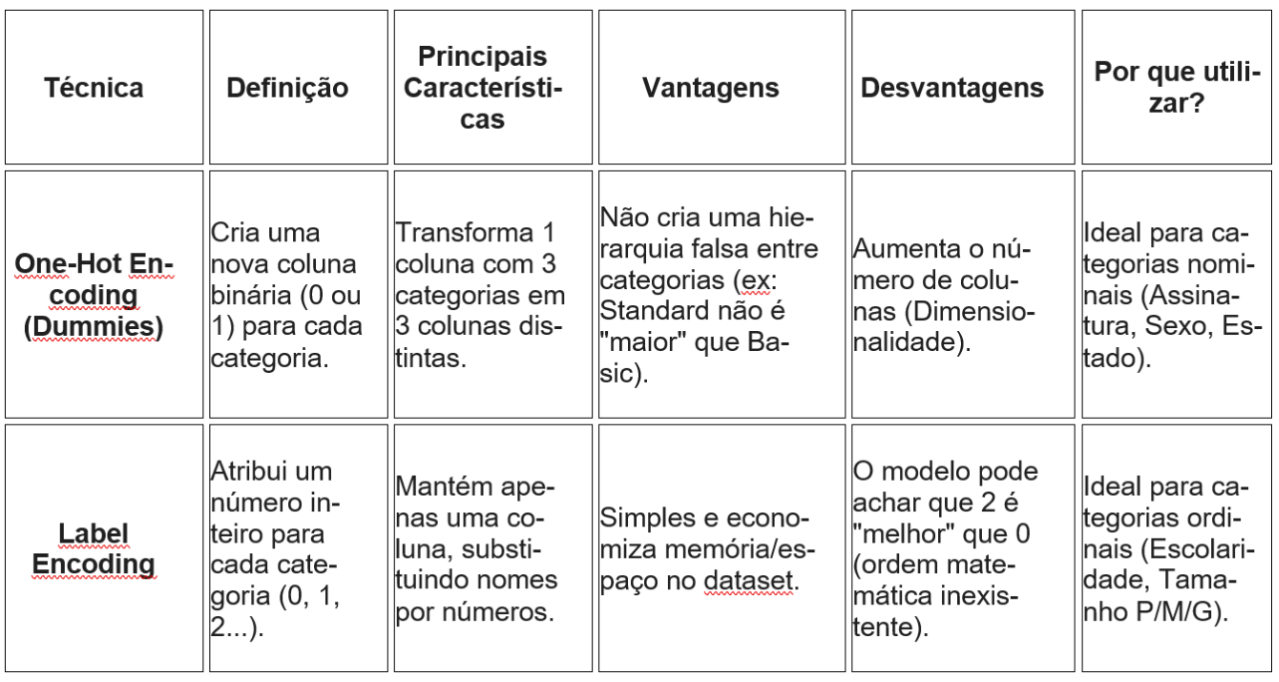

In [6]:
# 2) PREPARAÇÃO DOS DADOS (ENCODING & SCALING) ---

# Identificando colunas categóricas e numéricas
colunas_categoricas = ['sexo', 'assinatura', 'duracao_contrato']

colunas_numericas = ['idade', 'tempo_como_cliente', 'frequencia_uso', 
                     'ligacoes_callcenter', 'dias_atraso', 'meses_ultima_interacao', 'cancelou']



In [7]:
cancelamentos_df[colunas_numericas]

,idade,tempo_como_cliente,frequencia_uso,ligacoes_callcenter,dias_atraso,meses_ultima_interacao,cancelou
0,23.0,13.0,22.0,2.0,1.0,23.0,0.0
1,49.0,55.0,16.0,3.0,6.0,29.0,1.0
2,30.0,7.0,1.0,0.0,8.0,7.0,0.0
3,26.0,40.0,5.0,3.0,8.0,12.0,1.0
4,27.0,17.0,30.0,5.0,6.0,15.0,1.0
...,...,...,...,...,...,...,...
49995,62.0,35.0,7.0,2.0,8.0,15.0,1.0
49996,36.0,43.0,21.0,2.0,30.0,30.0,1.0
49997,55.0,42.0,8.0,1.0,12.0,27.0,1.0
49998,40.0,14.0,19.0,1.0,17.0,12.0,0.0


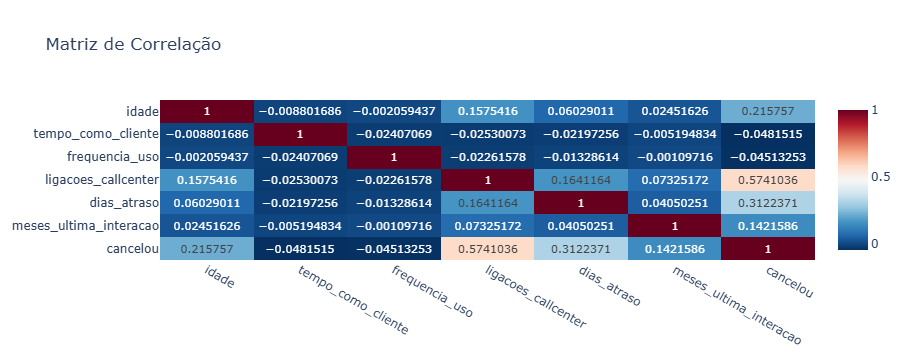

In [8]:
# Matriz de Correlação (Heatmap)
corr_matrix = cancelamentos_df[colunas_numericas].corr()

# 3. Criar o mapa de calor interativo com Plotly Express
fig_HM = px.imshow(
    corr_matrix,
    text_auto=True,  # Exibe os valores dentro dos quadrados
    color_continuous_scale='RdBu_r',  # Escala de cores (vermelho/azul)
    aspect="auto",
    title="Matriz de Correlação"
)

# 4. Exibir o gráfico no Jupyter
fig_HM.show()

In [9]:
# A. One-Hot Encoding (Conversão de Categorias)
cancelamentos2_df = pd.get_dummies(
                                  cancelamentos_df, 
                                  columns=colunas_categoricas, 
                                  drop_first=True, 
                                  dtype=int  
)

cancelamentos2_df.head()

,idade,tempo_como_cliente,frequencia_uso,ligacoes_callcenter,dias_atraso,total_gasto,meses_ultima_interacao,cancelou,sexo_Male,assinatura_Premium,assinatura_Standard,duracao_contrato_Monthly,duracao_contrato_Quarterly
0,23.0,13.0,22.0,2.0,1.0,909.58,23.0,0.0,1,0,1,0,0
1,49.0,55.0,16.0,3.0,6.0,207.00,29.0,1.0,1,1,0,1,0
2,30.0,7.0,1.0,0.0,8.0,768.78,7.0,0.0,1,0,0,0,0
3,26.0,40.0,5.0,3.0,8.0,398.00,12.0,1.0,1,1,0,0,0
4,27.0,17.0,30.0,5.0,6.0,507.00,15.0,1.0,0,0,0,0,0


In [10]:
# B. Separação de Variáveis
x = cancelamentos2_df .drop(columns=['total_gasto'])
y = cancelamentos2_df ['total_gasto']



In [11]:
x.head()

,idade,tempo_como_cliente,frequencia_uso,ligacoes_callcenter,dias_atraso,meses_ultima_interacao,cancelou,sexo_Male,assinatura_Premium,assinatura_Standard,duracao_contrato_Monthly,duracao_contrato_Quarterly
0,23.0,13.0,22.0,2.0,1.0,23.0,0.0,1,0,1,0,0
1,49.0,55.0,16.0,3.0,6.0,29.0,1.0,1,1,0,1,0
2,30.0,7.0,1.0,0.0,8.0,7.0,0.0,1,0,0,0,0
3,26.0,40.0,5.0,3.0,8.0,12.0,1.0,1,1,0,0,0
4,27.0,17.0,30.0,5.0,6.0,15.0,1.0,0,0,0,0,0


In [12]:
y.head()

0    909.58
1    207.00
2    768.78
3    398.00
4    507.00
Name: total_gasto, dtype: float64

In [13]:
# C. Train/Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

print("x_train =", x_train.shape)
print("y_train =", y_train.shape)
print("")
print("x_test =", x_test.shape)
print("y_test =", x_test.shape)

x_train = (34997, 12)
y_train = (34997,)

x_test = (14999, 12)
y_test = (14999, 12)


<h2 style="color : green">Standard Scaler</h2>

<pre>
Algoritmos baseados em distância, como o SVR, são muito sensíveis à escala. 
Se a idade vai até 60 e o tempo_como_cliente vai até 12, o SVR acharia que a idade é 5x mais importante.
O Scaler coloca tudo na mesma média (0) e desvio padrão (1).
</pre>

In [14]:
# D. Unificação de Escalas (Standard Scaler) - CRÍTICO para SVR
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

print("✅ Engenharia de Dados concluída.")

✅ Engenharia de Dados concluída.


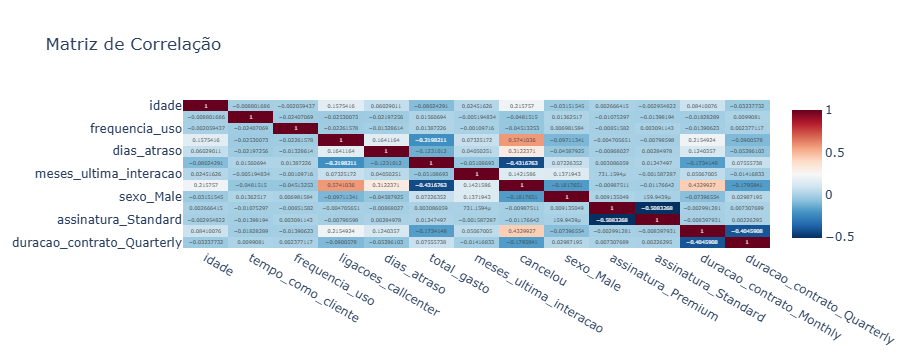

In [15]:
# Matriz de Correlação (Heatmap)
corr_matrix = cancelamentos2_df.corr()

# 3. Criar o mapa de calor interativo com Plotly Express
fig_HM = px.imshow(
    corr_matrix,
    text_auto=True,  # Exibe os valores dentro dos quadrados
    color_continuous_scale='RdBu_r',  # Escala de cores (vermelho/azul)
    aspect="auto",
    title="Matriz de Correlação"
)

# 4. Exibir o gráfico no Jupyter
fig_HM.show()

In [ ]:
!pip install statsmodels

<h2 style="color : green"> Regressão Linear Multipla</h2>

In [16]:
# Treinando o modelo com o Regressor linear Multiplo
model_rlm = LinearRegression()
model_rlm.fit(x_train, y_train) # Usa todas as colunas

# Previsão modelo com o Regressor linear Multiplo
y_pred_rlm = model_rlm.predict(x_test,)

print("y_pred_rlm =", y_pred_rlm.shape)
print("R2 RL Múltipla = ", r2_score(y_test, y_pred_rlm))



y_pred_rlm = (14999,)
R2 RL Múltipla =  0.1877591553834157


<h2 style="color : green"> Random Forest Regressor</h2>

In [17]:
# 1.2) Criando o Modelo (com 100 árvores)
# random_state garante que o resultado seja o mesmo toda vez que rodar
modelo_rfr = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Treinando o modelo (X_train e y_train do seu exemplo anterior)
modelo_rfr.fit(x_train, y_train)

# 3. Fazendo Previsões com RFR
y_pred_rfr = modelo_rfr.predict(x_test)
print("y_pred_rfr =", y_pred_rfr.shape)
print("R2 RFR = ", r2_score(y_test, y_pred_rfr))

y_pred_rfr = (14999,)
R2 RFR =  0.19746325032244216


<h2 style="color : green"> SVR com Kernel Linear  </h2>

<ul>
<li> Um modelo SVR linear é criado.</li> 
<li> C=100 controla a intensidade da penalidade de erro</li>
<li> epsilon=0,1 define a margem de tolerância.</li>
<li> O modelo aprende uma função de regressão linear.</li>
<li> As previsões são geradas com base em dados de teste.</li>
</ul>
<pre> 
    
modelo_SVR = SVR(kernel='linear', C=100, epsilon=0.1)
modelo_SVR.fit(X_train, y_train)

y_pred_SVR = modelo_SVR.predict(X_test)
</pre>

In [18]:
# --- CENÁRIO A: SVR COM KERNEL LINEAR ---

modelo_svr_kl = SVR(kernel='linear', C=100, epsilon=0.1)


modelo_svr_kl.fit(x_train_scaled, y_train)
y_pred_svr_kl = modelo_svr_kl.predict(x_test_scaled)


print("y_pred_svr_kl =", y_pred_svr_kl.shape)
print("R2 SVR com kernel Linear = ", r2_score(y_test, y_pred_svr_kl))

y_pred_svr_kl = (14999,)
R2 SVR com kernel Linear =  0.1855417341474147


<h2 style="color : green"> SVR COM KERNEL RBF (Radial Basis Function)</h2>

O modelo <b>Support Vector Regression (SVR) </b> com kernel RBF (Radial Basis Function) é uma técnica de aprendizado de máquina utilizada para prever valores contínuos (regressão) quando a relação entre as variáveis de entrada e a saída não é linear.

O kernel RBF permite que o algoritmo mapeie os dados para um espaço de dimensão superior, possibilitando a modelagem de padrões complexos e curvaturas nos dados. 


<b>C (Regularização)</b> : Controla o equilíbrio entre encontrar uma linha de regressão suave e minimizar o erro nos dados de treinamento.
Alto C: Tenta ajustar os dados de treinamento com muita precisão, o que pode levar a um modelo complexo e overfitting (ajuste excessivo).
Baixo C: Aceita uma margem maior e mais erros, resultando em um modelo mais simples e com melhor generalização, mas corre o risco de underfitting.


<b>Gamma ()</b> : Define a influência de um único exemplo de treinamento.
Alto Gamma: A influência é limitada, o que significa que o modelo tenta seguir muito de perto os pontos de dados individuais, causando overfitting.
Baixo Gamma: A influência é ampla, resultando em uma curva de regressão mais suave e generalizada. 


In [ ]:
modelo_svr_rbf = SVR(kernel='rbf', C=1e3, gamma=0.1)
# svr_rbf.fit(X_train, y_train)

modelo_svr_rbf.fit(x_train_scaled, y_train)
y_pred_svr_rbf = modelo_svr_rbf.predict(x_test_scaled)


print("y_pred_svr_rbf =", y_pred_svr_rbf.shape)

In [ ]:
# 4.  Calculando a Performance - Criando Tabela de Resultados no Console 
print("R2 RFR = ",  r2_score(y_test, y_pred_rfr))
print("MAE RFR  =", mean_absolute_error(y_test,y_pred_rfr))
print("RMSE RFR  =", np.sqrt(mean_squared_error(y_test, y_pred_rfr)))
print("MAPE RFR (%) = ", mean_absolute_percentage_error(y_test, y_pred_rfr))
print("")
print("")
print("R2 RL Múltipla = ", r2_score(y_test, y_pred_rlm))
print("MAE RL Múltipla  = ", mean_absolute_error(y_test, y_pred_rlm))
print("RMSE RL Múltipla  =", np.sqrt(mean_squared_error(y_test, y_pred_rlm)))
print("MAPE RLM (%) =", mean_absolute_percentage_error(y_test, y_pred_rlm))
    
print("")
print("")
print("R2 SVR com kernel Linear = ",  r2_score(y_test, y_pred_svr_kl))
print("MAE sem kernel Linear =", mean_absolute_error(y_test, y_pred_svr_kl))
print("RMSE kernel Linear =", np.sqrt(mean_squared_error(y_test, y_pred_svr_kl)))
print("MAPE SVR Kernel Linear (%) =", mean_absolute_percentage_error(y_test, y_pred_svr_kl))
print("")
print("")
print("R2 SVR kernel RBF = ",   r2_score(y_test, y_pred_svr_rbf))
print("MAE SVR kernel RBF =", mean_absolute_error(y_test, y_pred_svr_rbf))
print("RMSE SVR kernel RBF =", np.sqrt(mean_squared_error(y_test, y_pred_svr_rbf)))
print("MAPE SVR kernel RBF (%) = " , mean_absolute_percentage_error(y_test, y_pred_svr_rbf))



 <h2 style="color : green">Diagnóstico de Modelo</h2>
 Com um $R^2$ variando entre 0.10 e 0.19, a conclusão técnica é clara: A Regressão não é a abordagem ideal para este caso específico, e vou justificar o porquê com base nos números e na natureza dos seus dados.
 
<h2 style="color : green"> Análise Crítica dos Resultados </h2>
 O seu melhor modelo (Random Forest) explica apenas 19,7% da variância do total_gasto. Isso significa que mais de 80% do que faz o gasto de um cliente subir ou descer é "desconhecido" para esses algoritmos.
<ul>
 <li> <b> 1) O Problema do R² (Baixa Correlação)</b></li>
 Um $R^2$ tão baixo indica que as variáveis que temos (idade, dias_atraso, ligacoes_callcenter, etc.) não possuem uma relação linear ou estruturada forte o suficiente com o total_gasto para permitir uma previsão numérica precisa.

<li> <b>  2) O Erro Absoluto (MAE e RMSE)</b></li>
Seu MAE está em torno de 176 a 184. Se olharmos para o dataset, muitos valores de total_gasto estão na faixa de 400 a 800.
Errar 176 unidades em um valor de 500 representa um erro de quase 35% a 45% (confirmado pelo seu MAPE).
Para um negócio, uma previsão com 45% de erro médio é arriscada demais para tomar decisões financeiras.
</ul>


<h2 style="color : green"> Por que a Regressão está falhando aqui? </h2>
A resposta está na coluna cancelou.

No dataset cancelamentos.csv, a natureza do problema é intrinsecamente de <b>Classificação</b>. O total_gasto é uma consequência direta do tempo que o cliente ficou na base.

Clientes que cancelaram (cancelou = 1) interromperam seu ciclo de gastos precocemente.

Tentar prever o "gasto total" misturando quem saiu com quem ficou cria um ruído matemático enorme. O algoritmo não consegue traçar uma reta ou curva que sirva para os dois mundos ao mesmo tempo



<h2 style="color : green">A Regressão é o melhor algoritmo para este case? </h2>

<b> Não </b>. Pelo menos não da forma como os dados estão estruturados agora. <b>Este case é um exemplo clássico onde a Classificação traria muito mais valor ao cliente</b>.

O que seria mais eficiente fazer?

Mudar o Alvo: Em vez de prever quanto ele gastou (Regressão), prever se ele vai cancelar <b> (Classificação usando Logistic Regression ou Random Forest Classifier)</b>.

Filtragem (Se ainda quiser Regressão): Se o objetivo for realmente prever receita, você deve rodar a regressão apenas para os clientes ativos (cancelou = 0). O $R^2$ subiria drasticamente porque você removeria o ruído dos clientes que pararam de gastar.

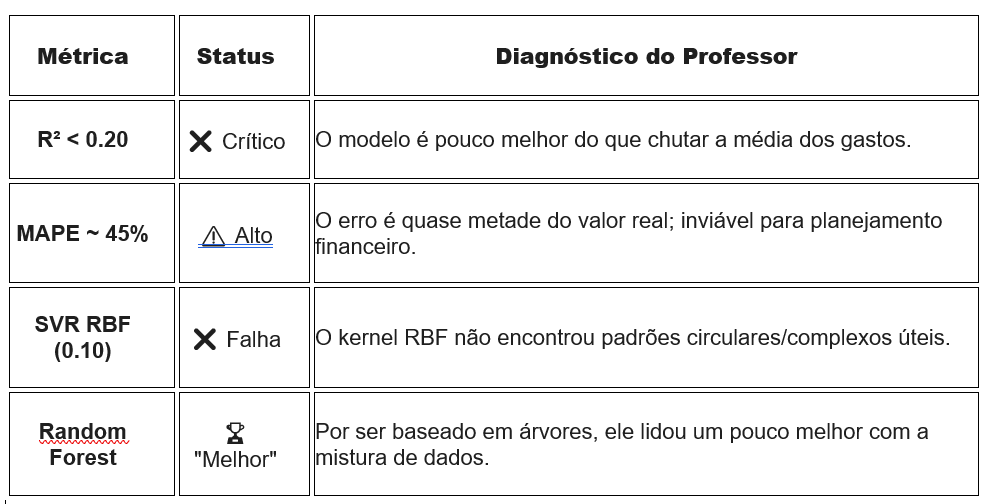
<h2 style="color : green"> Conclusão </h2>
Se eu fosse o seu gestor de Data Science, minha recomendação seria: <b>"Parem de tentar prever o valor exato do gasto e foquem em prever a probabilidade de cancelamento"</b>.

Evitar que um cliente saia <b>(Churn)</b> é muito mais valioso e estatisticamente viável neste dataset do que tentar adivinhar se ele vai gastar 500 ou 700 reais.

In [ ]:
# --- 4. MODELAGEM ---

modelos = {
    "Regressão Linear Múltipla": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR (Linear)": SVR(kernel='linear'),
    "SVR (RBF)": SVR(kernel='rbf')
}

resultados_lista = []

for nome, modelo in modelos.items():
    # Treinamento
    modelo.fit(x_train_scaled, y_train)
    
    # Predição
    y_pred = modelo.predict(x_test_scaled)
    
    # Métricas
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    resultados_lista.append({
        "Algoritmo": nome,
        "R2": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE (%)": mape * 100
    })



In [ ]:
# --- 5. RESULTADOS FINAIS ---
df_metricas = pd.DataFrame(resultados_lista).sort_values(by="R2", ascending=False)

print("\n TABELA COMPARATIVA DE MÉTRICAS:")
print(df_metricas.to_string(index=False))

# Visualização da Melhor Performance
fig_ranking = px.bar(df_metricas, x="Algoritmo", y="R2", color="R2",
                     title="Ranking de Performance (R² Score)")
fig_ranking.show()

<h2 style="color : green"> Exportando DataFrame para CSV no Pandas </h2>



O método .to_csv() é um dos métodos mais comuns da biblioteca Pandas utilizados para exportar DataFrames para arquivos CSV. Este método possui vários parâmetros que permitem personalizar o processo de exportação.

Este método .to_csv() serve para salvar o DataFrame como um arquivo CSV chamado 'titanic-limpo.csv'.

O parâmetro index especifica se deve ou não incluir o índice do DataFrame no arquivo CSV. Por padrão, esse parâmetro é definido como True. Quando definido como False, o Pandas exclui o índice do DataFrame do arquivo CSV salvo.

<h2 style="color : green"> Sintaxe</h2>

df.to_csv()

In [ ]:
cancelamentosLimpo_df.to_csv("Dados2026/cancelamentosLimpo_df.csv", index= False)                   


In [ ]:
cancelamentoLimpo_df = pd.read_csv("Dados2026/cancelamentos-limpo.csv")
cancelamentoLimpo_df
